# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

Types, Shape, Head 

ID                            int64
OPEID                         int64
Institution Name                str
City                            str
State                           str
Foreign Gift Received Date    int64
Foreign Gift Amount           int64
Gift Type                       str
Country of Giftor               str
Giftor Name                     str
dtype: object 
 (28221, 10) 
 <bound method NDFrame.head of           ID    OPEID                     Institution Name          City  \
0          1   102000        Jacksonville State University  Jacksonville   
1          2   104700                      Troy University          Troy   
2          3   105100                University of Alabama    Tuscaloosa   
3          4   105100                University of Alabama    Tuscaloosa   
4          5   105100                University of Alabama    Tuscaloosa   
...      ...      ...                                  ...           ...   
28216  28217  4279700  Albe

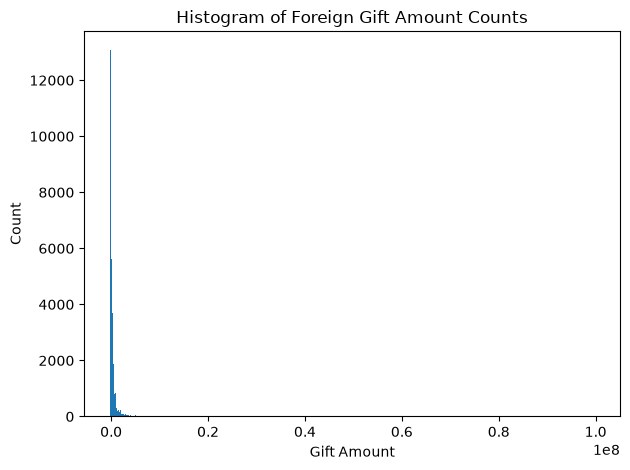

Foreign Gift Amount Info
<bound method Series.max of 0         250000
1         463657
2        3649107
3           1000
4          49476
          ...   
28216     381717
28217     444938
28218    1064580
28219     737375
28220    1024469
Name: Foreign Gift Amount, Length: 28221, dtype: int64> 
 
 
 <bound method Series.min of 0         250000
1         463657
2        3649107
3           1000
4          49476
          ...   
28216     381717
28217     444938
28218    1064580
28219     737375
28220    1024469
Name: Foreign Gift Amount, Length: 28221, dtype: int64>


In [2]:
# Your Phase 1 solution to the problem goes here.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('./data/ForeignGifts_edu.csv')
print("Types, Shape, Head \n")
print(df.dtypes, '\n',df.shape, '\n', df.head)
df_fga = df["Foreign Gift Amount"]

df['Foreign Gift Amount'].hist(bins=500, grid=False)
plt.title("Histogram of Foreign Gift Amount Counts")
plt.xlabel("Gift Amount")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Foreign Gift Amount Info")
df_fga = df["Foreign Gift Amount"]
print(df['Foreign Gift Amount'].max, "\n \n \n", df['Foreign Gift Amount'].min)

#Looking at the histogram and other supplementary info we can pull from the dataframe, we can see that the gift amounts skew heavily towards the lower end of the spectrum $(0.0-0.05x10^8). Looking closely, we can see the 50 bins aren't a perfect right skew, and some values may be more commonly occuring than others, but it's a generally consistent looking histogram.




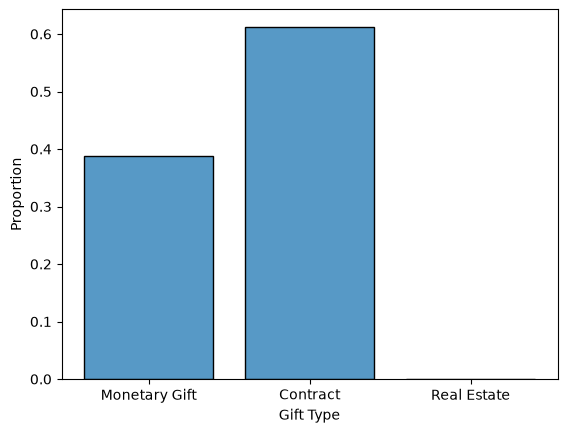

/workspaces/A02-eda-and-visualization/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


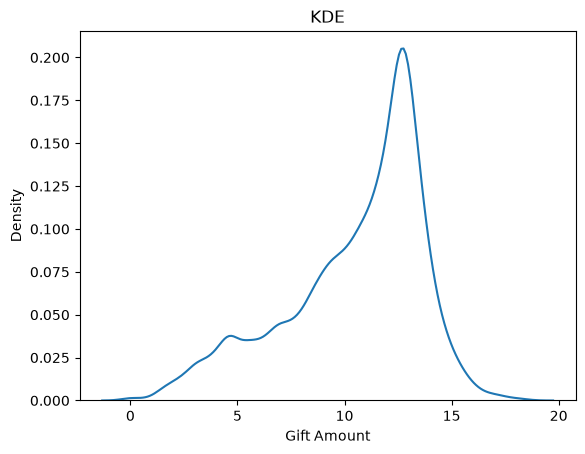

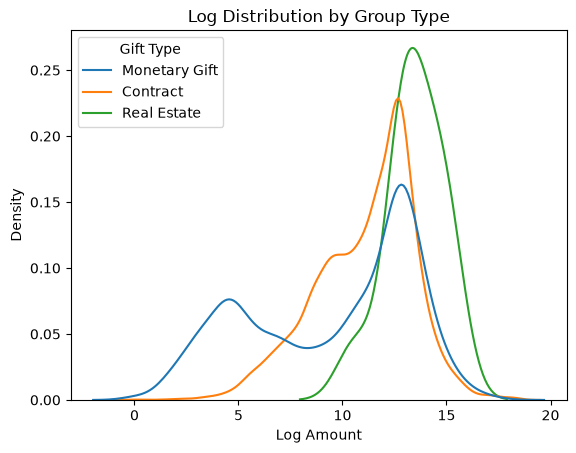

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64

 
 
 Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

 
 
 G

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('./data/ForeignGifts_edu.csv')

#Q2.3 -- Histogram/Value Counts for Gift Type


plot = sns.histplot(data = df,x = "Gift Type",stat = "proportion",discrete = True, shrink = 0.8)
plot.set(xlabel = "Gift Type", ylabel = "Proportion")
plt.show()

df["Gift Type"].value_counts()
# 17274/28221 or 61.2% are Contracts, 10936/28221 or 38.8% are Monetary Gifts, and 11/28221 or 0.0004% are Real Estate.

#Q2.4-2.6
data = np.log(df["Foreign Gift Amount"])
ax = sns.kdeplot(x=data, bw_method = "silverman", label = "Logarithm of Foreign Gift Amount KDE")
ax.set(title = "KDE", xlabel = "Gift Amount", ylabel = "Density")
plt.show()

ax2 = sns.kdeplot(x = data, hue = df["Gift Type"], common_norm = False, bw_method = "silverman")
ax2.set(title = "Log Distribution by Group Type",xlabel = "Log Amount", ylabel = "Density")
plt.show()

#This color-differentiated KDE shows me that the values of the real estate group are most clustered, followed then by contracts and finally monetary gifts. 

top_country_num_gifts = df["Country of Giftor"].value_counts().head(15)
print(top_country_num_gifts)

top_country_qty_gifts = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending = False)
print("\n \n \n", top_country_qty_gifts.head(15))

top_giftors = df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending = False)
print("\n \n \n",top_giftors.head(10))

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]